# IMPORTACIÓN DE LIBRERÍAS


In [96]:
# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# CARGA DEL DATASET


In [97]:
# CARGA DEL DATASET

# Cargamos el archivo CSV desde la carpeta Data
df = pd.read_csv("../Data/cleaned_tourist_accommodation_27_04.csv")

# EXPLORACIÓN DEL DATASET


In [98]:
# EXPLORACIÓN DEL DATASET

# Mostramos las primeras filas para entender la estructura
df.head(5)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,review_scores_rating_clean,price_imputed
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1.0,...,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018,97.0,400.0
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020,92.0,170.0
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019,98.0,990.0
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020,94.0,400.0
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2.0,...,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019,97.0,900.0


In [99]:
# Revisamos las columnas disponibles
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'review_scores_rating_clean',
       'price_imputed'],
      dtype='object')

# LIMPIEZA

## limpiamos la neighbourhood_name

In [100]:
df["neighbourhood_clean"] = df["neighbourhood_name"]

In [101]:
df["neighbourhood_clean"] = df["neighbourhood_clean"].str.lower()

In [102]:
df["neighbourhood_clean"] = df["neighbourhood_clean"].str.replace(
    r"^(el |la |l')", "", regex=True
)

In [103]:
df["neighbourhood_clean"] = df["neighbourhood_clean"].str.strip()

## limpiamos amenities_list

In [104]:
df["amenities_clean"] = df["amenities_list"].str.lower()

In [105]:
df["pool"] = df["amenities_clean"].str.contains("pool", na=False).astype(int)

df["hot_tub"] = df["amenities_clean"].str.contains(
    "hot tub|jacuzzi", na=False
).astype(int)

df["parking"] = df["amenities_clean"].str.contains(
    "parking", na=False
).astype(int)

df["air_conditioning"] = df["amenities_clean"].str.contains(
    "air conditioning|ac", na=False
).astype(int)

In [106]:
df.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'review_scores_rating_clean',
       'price_imputed', 'neighbourhood_clean', 'amenities_clean', 'pool',
       'hot_tub', 'parking', 'air_conditioning'],
      dtype='object')

# ANALISI

## INTRO

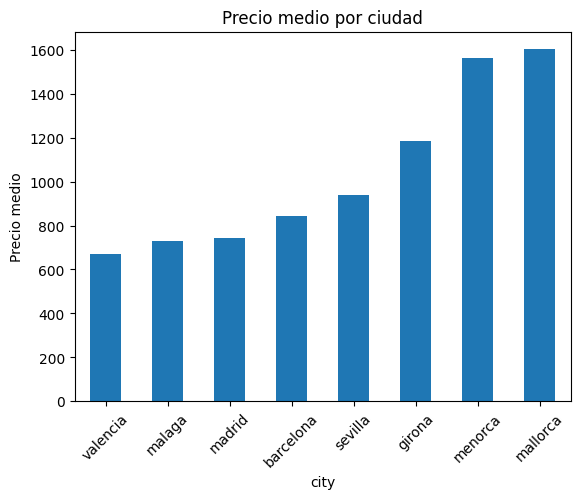

In [107]:
# precio medio por ciutad

df.groupby("city")["price_imputed"].mean().sort_values().plot(kind="bar")
plt.title("Precio medio por ciudad")
plt.ylabel("Precio medio")
plt.xticks(rotation=45)
plt.show()

### storytelling: ya sabemos que el precio cambia mucho de ciutad en ciutad. Pero quales son las variables que mas impactan?

#### 1. Como impacta en el precio la capacidad de los alojamento?

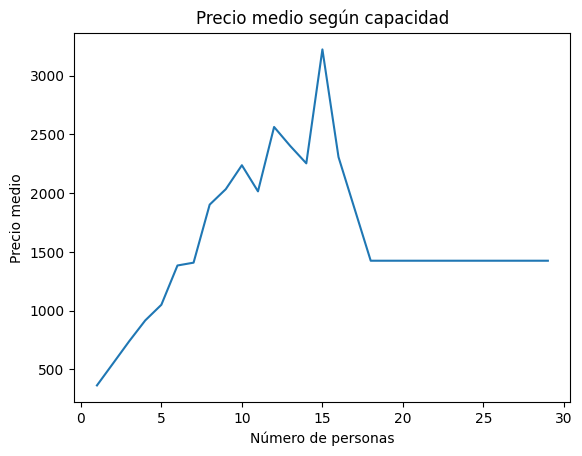

In [108]:
# diferencia de precio por capacidad

import matplotlib.pyplot as plt

df.groupby("accommodates")["price_imputed"].mean().plot(kind="line")
plt.title("Precio medio según capacidad")
plt.xlabel("Número de personas")
plt.ylabel("Precio medio")
plt.show()

#### 2. Como impactan en el precio los servicios más solicitados por los huespedes?
[(fuente: Airbnb)](https://www.airbnb.com.ar/resources/hosting-homes/a/los-servicios-que-quieren-los-huspedes-25)

In [109]:
import pandas as pd

amenities = ["pool", "hot_tub", "parking", "air_conditioning"]

data = []

for amenity in amenities:
    for value in [0, 1]:
        mean_price = df[df[amenity] == value]["price_imputed"].mean()
        
        data.append({
            "amenity": amenity,
            "presencia": "Sí" if value == 1 else "No",
            "precio_medio": mean_price
        })

df_plot = pd.DataFrame(data)

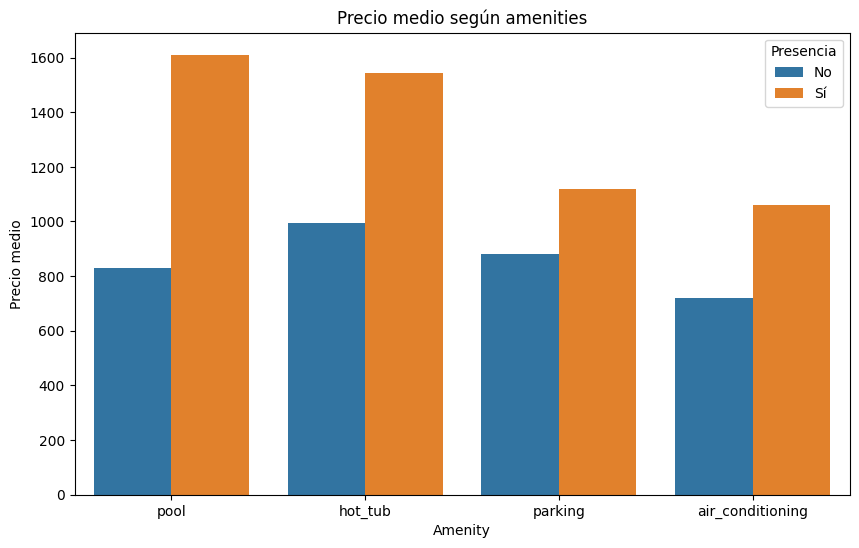

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x="amenity",
    y="precio_medio",
    hue="presencia"
)

plt.title("Precio medio según amenities")
plt.ylabel("Precio medio")
plt.xlabel("Amenity")
plt.legend(title="Presencia")
plt.show()

#### Storytelling: para saber qual variable influye mas y cuanto (en euro) hacemos una regresion:

## REGRESIÓN CON RANDOM FOREST
Nos dice qué variable influye más en el precio (pero no nos dice cuánto en términos de euros)

In [111]:
# Import librerie
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [112]:
# =========================
# PREPARACIÓN DEL DATASET
# =========================

# Variabili da usare
features = [
    "accommodates",
    "pool",
    "hot_tub",
    "parking",
    "air_conditioning"
]

target = "price_imputed"

# Dataset per il modello
df_rf = df[
    ["city", target] + features
].dropna()


In [113]:
# RANDOM FOREST GENERAL (no dividido por ciudad)
# Un valo más alto = más importante (influye mas sobre el precio)

X = df_rf[features]
y = df_rf[target]

rf_general = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_general.fit(X, y)

# Importanza variabili generale
rf_general_importance = (
    pd.Series(rf_general.feature_importances_, index=features)
    .sort_values(ascending=False)
)

rf_general_importance

# más alto = más importante

accommodates        0.876188
pool                0.065018
air_conditioning    0.025171
parking             0.021498
hot_tub             0.012125
dtype: float64

Insight: Ya se vee que accomodates influye mucho mas que las otras variables.

In [114]:
# RANDOM FOREST POR CIUTAD

rf_results = {}

for city in df_rf["city"].unique():
    
    df_city = df_rf[df_rf["city"] == city].copy()
    
    X_city = df_city[features]
    y_city = df_city[target]
    
    rf_city = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    
    rf_city.fit(X_city, y_city)
    
    rf_results[city] = pd.Series(
        rf_city.feature_importances_,
        index=features
    )

# Tabella città x variabili
rf_city_df = pd.DataFrame(rf_results).T

# Tabella colorata
rf_city_df.style.background_gradient(cmap="Blues", axis=None)

,accommodates,pool,hot_tub,parking,air_conditioning
malaga,0.651548,0.151528,0.029237,0.068502,0.099185
madrid,0.823026,0.030078,0.019331,0.100364,0.027201
sevilla,0.734532,0.097552,0.013000,0.093440,0.061476
barcelona,0.893157,0.027506,0.022686,0.029234,0.027417
girona,0.737754,0.099587,0.037267,0.057966,0.067426
valencia,0.830977,0.030933,0.032177,0.069754,0.036158
mallorca,0.780559,0.105668,0.029264,0.043619,0.040890
menorca,0.775580,0.076219,0.025427,0.058469,0.064304


Insight: Para todas las ciudades, accommodates influye más en el precio.

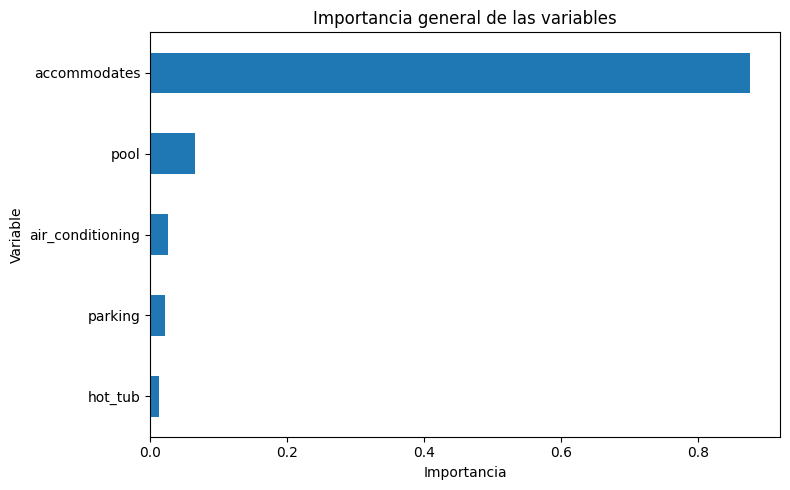

In [115]:
# GRAFICO GENERAL

rf_general_importance.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Importancia general de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

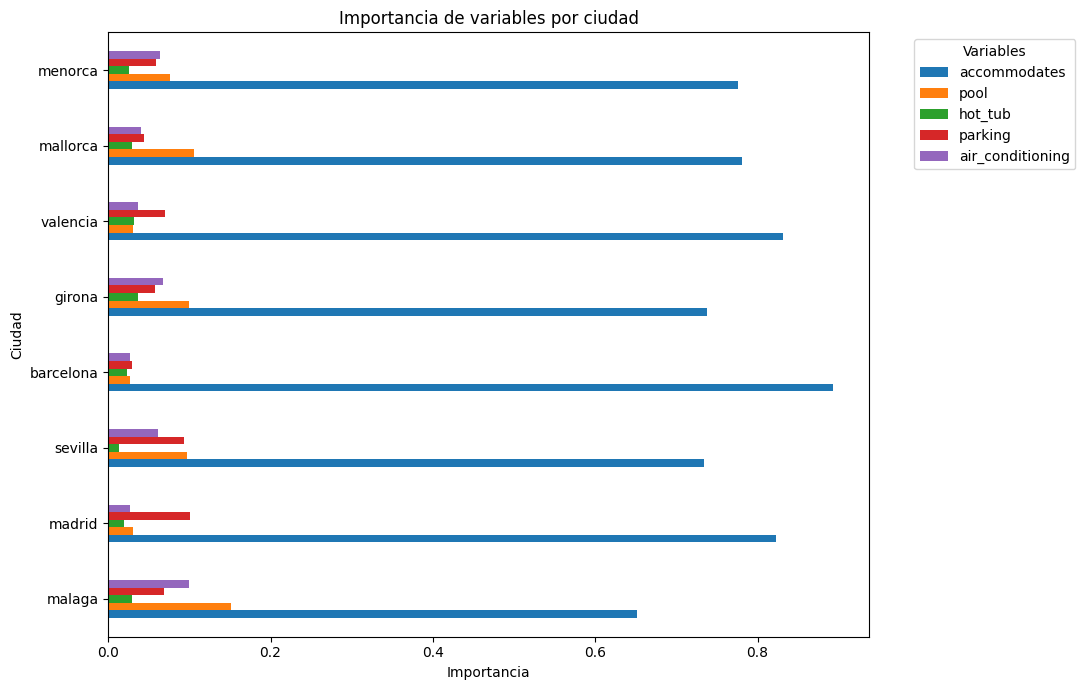

In [116]:
# GRAFICO POR CIUTAD

rf_city_df.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.title("Importancia de variables por ciudad")
plt.xlabel("Importancia")
plt.ylabel("Ciudad")
plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

_____________

## REGRESIÓN LINEAL
Nos dice también CUANTO cambia el precio en función de la variable

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [118]:
# preparacion del dataset

features = ["accommodates", "pool", "hot_tub", "parking", "air_conditioning"]
target = "price_imputed"

df_lin = df[["city", target] + features].dropna()

In [119]:
# regression general

model_general = smf.ols(
    formula="price_imputed ~ accommodates + pool + hot_tub + parking + air_conditioning",
    data=df_lin
).fit()

coef_general = model_general.params.drop("Intercept")
coef_general

accommodates        165.119152
pool                353.364904
hot_tub              95.060789
parking             -46.081291
air_conditioning    138.372299
dtype: float64

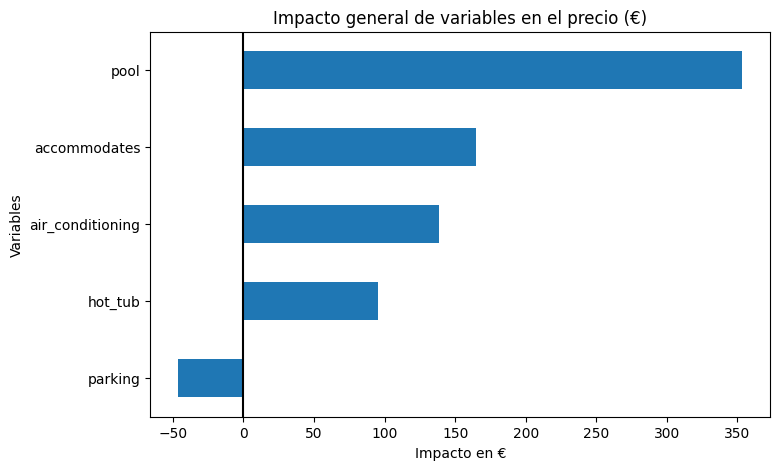

In [120]:
# visualizacion general

coef_general.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Impacto general de variables en el precio (€)")
plt.xlabel("Impacto en €")
plt.ylabel("Variables")
plt.axvline(0, color="black")
plt.show()

In [121]:
# regression por ciutad

results = {}

for city in df_lin["city"].unique():
    
    df_city = df_lin[df_lin["city"] == city]
    
    model = smf.ols(
        formula="price_imputed ~ accommodates + pool + hot_tub + parking + air_conditioning",
        data=df_city
    ).fit()
    
    results[city] = model.params

In [122]:
# tabla por ciutad

coef_df = []

for city, coef in results.items():
    temp = coef.copy()
    temp["city"] = city
    coef_df.append(temp)

coef_df = pd.DataFrame(coef_df)

coef_df_clean = coef_df.set_index("city").drop(columns=["Intercept"], errors="ignore")

coef_df_clean.style.background_gradient(
    cmap="RdYlGn",
    axis=None,
    vmin=-coef_df_clean.abs().max().max(),
    vmax=coef_df_clean.abs().max().max()
)

,accommodates,pool,hot_tub,parking,air_conditioning
city,,,,,
malaga,113.338451,241.050558,318.132548,-31.284782,16.945188
madrid,157.235127,145.705309,46.950426,-37.323805,64.298089
sevilla,153.201699,417.311066,119.378278,-112.364056,-15.830354
barcelona,195.705404,290.648710,54.251818,-52.185734,158.560017
girona,165.273727,257.082940,-132.443367,32.645599,221.694148
valencia,127.348517,10.294903,323.415127,-46.818087,5.875734
mallorca,133.937507,443.903558,234.830534,68.568412,22.197016
menorca,220.232837,283.142640,-3.964573,-270.884915,76.924844


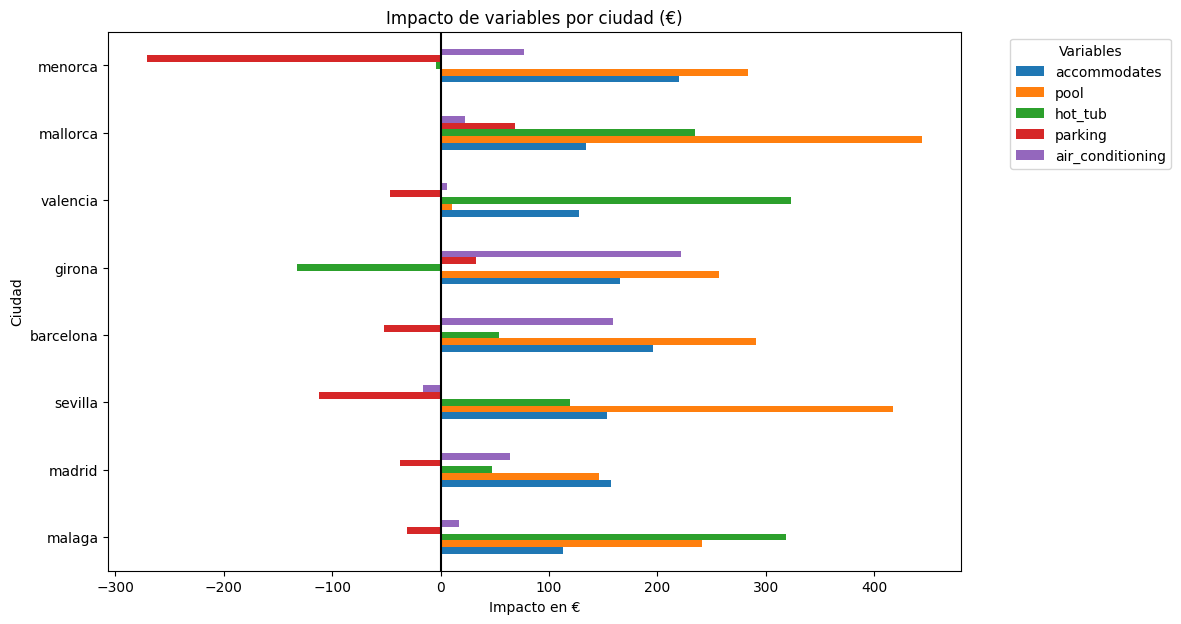

In [123]:
# visualizacion por ciutad

coef_df_clean.plot(kind="barh", figsize=(11,7))

plt.title("Impacto de variables por ciudad (€)")
plt.xlabel("Impacto en €")
plt.ylabel("Ciudad")
plt.axvline(0, color="black")
plt.legend(title="Variables", bbox_to_anchor=(1.05, 1))
plt.show()

______________

## (BORRAR de aquí abajo) REGRESIÓN LINEAL
Nos dice también CUANTO cambia el precio en función de la variable

In [124]:
# modelo

df_model = df[
    ["price_imputed", "accommodates", "room_type", "city",
     "pool", "hot_tub", "parking", "air_conditioning"]
].dropna()

In [125]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
import statsmodels.formula.api as smf

In [127]:
df_model = df[
    ["price_imputed", "accommodates", "room_type", "city",
     "pool", "hot_tub", "parking", "air_conditioning"]
].dropna()

In [128]:
model = smf.ols(
    formula="price_imputed ~ accommodates + C(room_type) + C(city) + pool + hot_tub + parking + air_conditioning",
    data=df_model
).fit()

In [129]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          price_imputed   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     360.5
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:48:12   Log-Likelihood:                -60602.
No. Observations:                7690   AIC:                         1.212e+05
Df Residuals:                    7674   BIC:                         1.213e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [130]:
df_model[["pool", "hot_tub", "parking", "air_conditioning"]].mean()

pool                0.228739
hot_tub             0.022757
parking             0.530169
air_conditioning    0.848505
dtype: float64

### IMPACTO DE LA CAPACIDAD
muestra cómo cambia el precio con accommodates

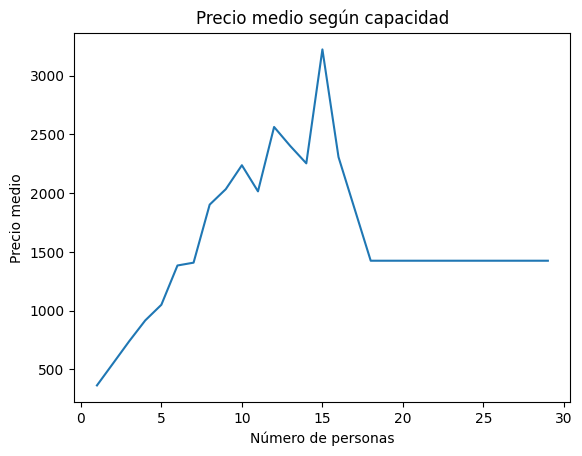

In [131]:
import matplotlib.pyplot as plt

df.groupby("accommodates")["price_imputed"].mean().plot(kind="line")
plt.title("Precio medio según capacidad")
plt.xlabel("Número de personas")
plt.ylabel("Precio medio")
plt.show()

DIFERENCIA ENTRE CIUDADES

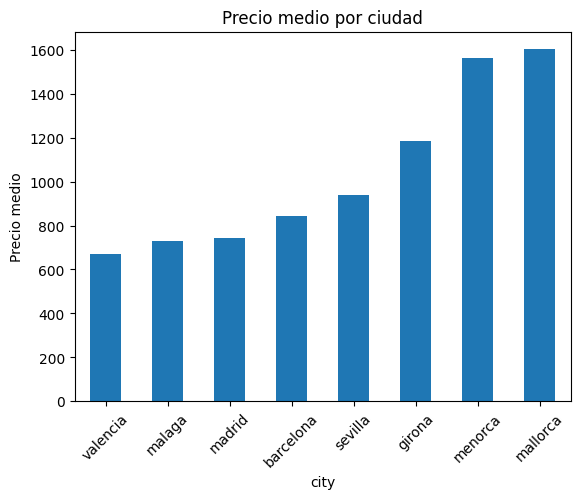

In [132]:
df.groupby("city")["price_imputed"].mean().sort_values().plot(kind="bar")
plt.title("Precio medio por ciudad")
plt.ylabel("Precio medio")
plt.xticks(rotation=45)
plt.show()

AMENITIES

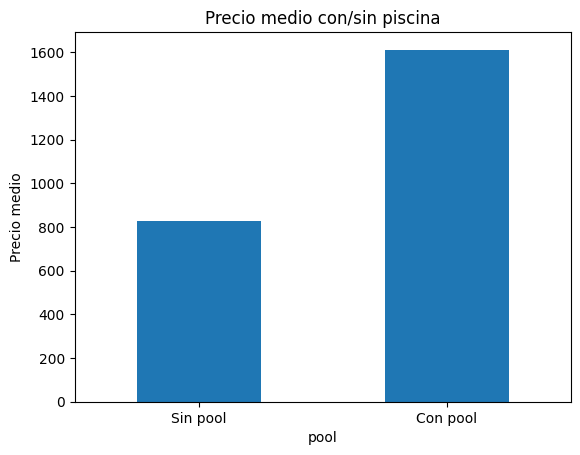

In [133]:
df.groupby("pool")["price_imputed"].mean().plot(kind="bar")
plt.title("Precio medio con/sin piscina")
plt.xticks([0,1], ["Sin pool", "Con pool"], rotation=0)
plt.ylabel("Precio medio")
plt.show()

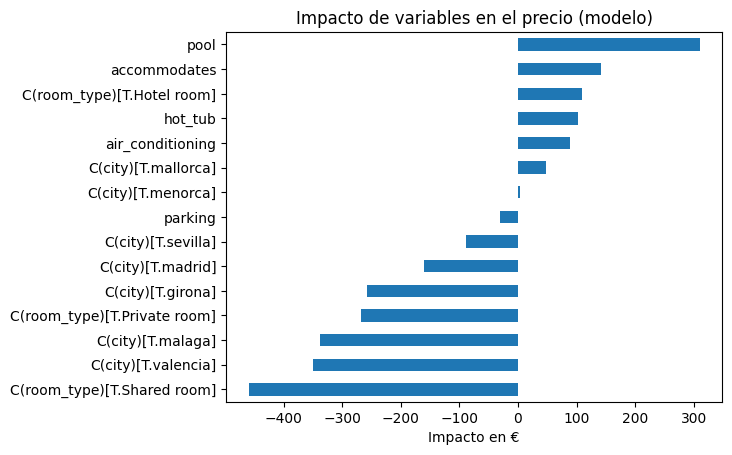

In [134]:
import pandas as pd

coef = model.params.drop("Intercept")

coef.sort_values().plot(kind="barh")
plt.title("Impacto de variables en el precio (modelo)")
plt.xlabel("Impacto en €")
plt.show()

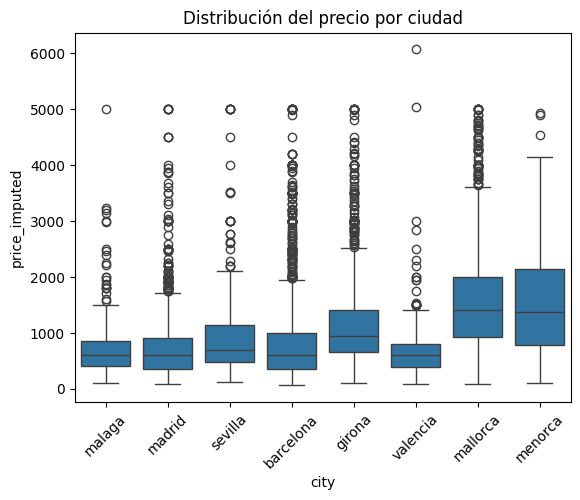

In [135]:
import seaborn as sns

sns.boxplot(x="city", y="price_imputed", data=df)
plt.xticks(rotation=45)
plt.title("Distribución del precio por ciudad")
plt.show()

Por cada ciutad

In [136]:
results = {}

for city in df["city"].unique():
    
    df_city = df[df["city"] == city][
        ["price_imputed", "accommodates", "room_type",
         "pool", "hot_tub", "parking", "air_conditioning"]
    ].dropna()
    
    model = smf.ols(
        formula="price_imputed ~ accommodates + C(room_type) + pool + hot_tub + parking + air_conditioning",
        data=df_city
    ).fit()
    
    results[city] = model

In [137]:
for city, model in results.items():
    print("\n\n", city)
    print(model.summary())



 malaga
                            OLS Regression Results                            
Dep. Variable:          price_imputed   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     24.02
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.55e-30
Time:                        18:48:13   Log-Likelihood:                -2946.9
No. Observations:                 394   AIC:                             5912.
Df Residuals:                     385   BIC:                             5948.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

versione visiva

In [138]:
coef_df = []

for city, model in results.items():
    coef = model.params
    coef["city"] = city
    coef_df.append(coef)

coef_df = pd.DataFrame(coef_df)
coef_df

,Intercept,C(room_type)[T.Hotel room],C(room_type)[T.Private room],C(room_type)[T.Shared room],accommodates,pool,hot_tub,parking,air_conditioning,city
0,424.210777,-34.237242,-249.742079,-1066.671514,104.505014,256.042575,312.249870,-21.387663,-95.540071,malaga
1,480.818672,68.753671,-310.019588,-424.210696,115.620040,136.175892,66.526454,-46.574306,-1.884414,madrid
2,551.221008,18.492597,-170.472132,-1417.707663,136.371712,506.840693,71.643405,-106.447668,-65.840886,sevilla
3,470.320486,284.859078,-348.345359,-466.459349,148.708915,266.746450,66.774765,-57.135988,90.207865,barcelona
4,-60.310102,-230.767031,-58.513221,NaN,163.601285,255.843048,-131.897810,35.170038,218.832847,girona
5,384.228832,60.317798,-183.076999,-308.893415,100.034971,4.028011,285.445607,-53.053298,-36.703161,valencia
6,513.603724,276.379161,-248.477473,-426.450121,126.656727,429.325965,238.334413,66.238427,-11.753580,mallorca
7,203.071913,NaN,-84.573018,NaN,217.555110,277.153192,-0.321988,-269.517783,71.309936,menorca


In [139]:
cols = ["accommodates", "pool", "hot_tub", "parking", "air_conditioning"]

coef_df_clean = coef_df.set_index("city")[cols]

coef_df_clean.style.background_gradient(cmap="coolwarm")

,accommodates,pool,hot_tub,parking,air_conditioning
city,,,,,
malaga,104.505014,256.042575,312.249870,-21.387663,-95.540071
madrid,115.620040,136.175892,66.526454,-46.574306,-1.884414
sevilla,136.371712,506.840693,71.643405,-106.447668,-65.840886
barcelona,148.708915,266.746450,66.774765,-57.135988,90.207865
girona,163.601285,255.843048,-131.897810,35.170038,218.832847
valencia,100.034971,4.028011,285.445607,-53.053298,-36.703161
mallorca,126.656727,429.325965,238.334413,66.238427,-11.753580
menorca,217.555110,277.153192,-0.321988,-269.517783,71.309936


In [140]:
coef_df_clean.style.background_gradient(
    cmap="RdYlGn",
    axis=None,
    vmin=-coef_df_clean.abs().max().max(),
    vmax=coef_df_clean.abs().max().max()
)

,accommodates,pool,hot_tub,parking,air_conditioning
city,,,,,
malaga,104.505014,256.042575,312.249870,-21.387663,-95.540071
madrid,115.620040,136.175892,66.526454,-46.574306,-1.884414
sevilla,136.371712,506.840693,71.643405,-106.447668,-65.840886
barcelona,148.708915,266.746450,66.774765,-57.135988,90.207865
girona,163.601285,255.843048,-131.897810,35.170038,218.832847
valencia,100.034971,4.028011,285.445607,-53.053298,-36.703161
mallorca,126.656727,429.325965,238.334413,66.238427,-11.753580
menorca,217.555110,277.153192,-0.321988,-269.517783,71.309936


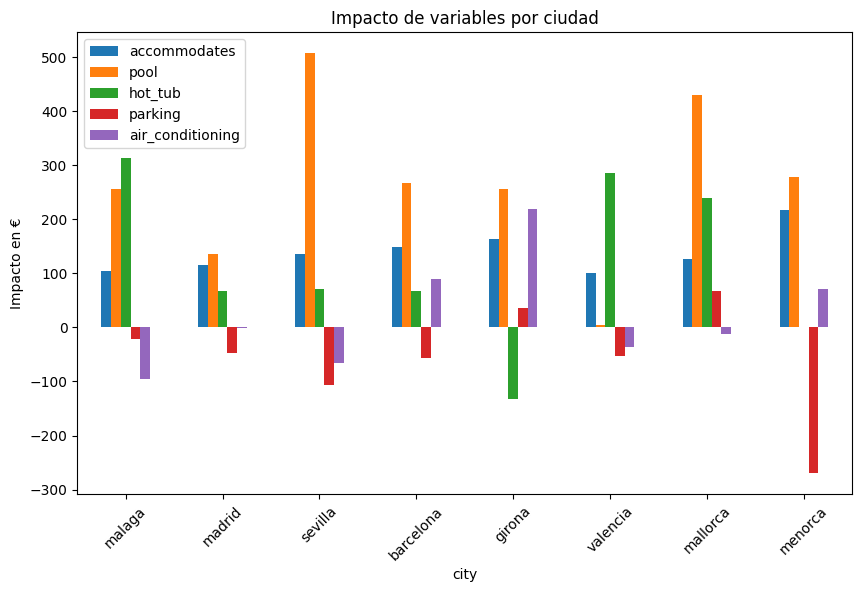

In [141]:
coef_df.set_index("city")[[
    "accommodates", "pool", "hot_tub", "parking", "air_conditioning"
]].plot(kind="bar", figsize=(10,6))

plt.title("Impacto de variables por ciudad")
plt.ylabel("Impacto en €")
plt.xticks(rotation=45)
plt.show()